In [2]:
import os

BASE_DATASET_PATH = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
WORKING_DIR       = '/kaggle/working'
CHECKPOINT_DIR    = os.path.join(WORKING_DIR, 'checkpoints')
LOG_DIR           = os.path.join(WORKING_DIR, 'logs')
EXPORT_DIR        = os.path.join(WORKING_DIR, 'exports')
IMAGE_SIZE        = (300, 300)
IMAGE_SHAPE       = (300, 300, 3)
BATCH_SIZE        = 32
NUM_CLASSES       = 38
RANDOM_SEED       = 42
TRAIN_SPLIT       = 0.8
VAL_SPLIT         = 0.1
TEST_SPLIT        = 0.1

for directory in [CHECKPOINT_DIR, LOG_DIR, EXPORT_DIR]:
    os.makedirs(directory, exist_ok=True)

CLASS_NAMES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy',
]

print(f"✓ Config loaded")

✓ Config loaded


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.19.0
GPU available      : True


In [5]:
all_paths  = []
all_labels = []

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(BASE_DATASET_PATH, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    for img_name in images:
        all_paths.append(os.path.join(class_path, img_name))
        all_labels.append(label_idx)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total images collected : {len(all_paths):,}")
print(f"Total labels collected : {len(all_labels):,}")
print(f"Unique classes found   : {len(np.unique(all_labels))}")
print(f"Label range            : {all_labels.min()} → {all_labels.max()}")

Total images collected : 54,305
Total labels collected : 54,305
Unique classes found   : 38
Label range            : 0 → 37


In [6]:
# ── Step 1: Split off test set first ─────────────────────────
paths_trainval, paths_test, labels_trainval, labels_test = train_test_split(
    all_paths,
    all_labels,
    test_size=TEST_SPLIT,
    stratify=all_labels,
    random_state=RANDOM_SEED
)

# ── Step 2: Split remaining into train and val ────────────────
# Val is 10% of total, which is 11.1% of the remaining 90%
val_size_adjusted = VAL_SPLIT / (TRAIN_SPLIT + VAL_SPLIT)

paths_train, paths_val, labels_train, labels_val = train_test_split(
    paths_trainval,
    labels_trainval,
    test_size=val_size_adjusted,
    stratify=labels_trainval,
    random_state=RANDOM_SEED
)

print(f"{'='*45}")
print(f"SPLIT SUMMARY")
print(f"{'='*45}")
print(f"Training set   : {len(paths_train):,} images ({len(paths_train)/len(all_paths)*100:.1f}%)")
print(f"Validation set : {len(paths_val):,} images ({len(paths_val)/len(all_paths)*100:.1f}%)")
print(f"Test set       : {len(paths_test):,} images ({len(paths_test)/len(all_paths)*100:.1f}%)")
print(f"Total          : {len(paths_train)+len(paths_val)+len(paths_test):,} images")
print(f"{'='*45}")

# ── Verify stratification worked ─────────────────────────────
print("\nStratification check (first 5 classes):")
print(f"{'Class':<45} {'Train':>7} {'Val':>6} {'Test':>6}")
print("-" * 65)
for i, name in enumerate(CLASS_NAMES[:5]):
    tr = np.sum(labels_train == i)
    vl = np.sum(labels_val == i)
    te = np.sum(labels_test == i)
    print(f"{name:<45} {tr:>7} {vl:>6} {te:>6}")

SPLIT SUMMARY
Training set   : 43,443 images (80.0%)
Validation set : 5,431 images (10.0%)
Test set       : 5,431 images (10.0%)
Total          : 54,305 images

Stratification check (first 5 classes):
Class                                           Train    Val   Test
-----------------------------------------------------------------
Apple___Apple_scab                                504     63     63
Apple___Black_rot                                 497     62     62
Apple___Cedar_apple_rust                          220     28     27
Apple___healthy                                  1315    165    165
Blueberry___healthy                              1202    150    150


In [7]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)

class_weight_dict = {
    idx: weight
    for idx, weight in enumerate(class_weights_array)
}

# ── Save class weights to disk ────────────────────────────────
weights_path = os.path.join(EXPORT_DIR, 'class_weights.json')
with open(weights_path, 'w') as f:
    json.dump(class_weight_dict, f, indent=2)

print("Class weights (sample — highest and lowest):")
print(f"{'='*55}")

sorted_weights = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)

print("Most penalized (minority classes):")
for idx, weight in sorted_weights[:3]:
    print(f"  {CLASS_NAMES[idx]:<45} weight: {weight:.4f}")

print("\nLeast penalized (majority classes):")
for idx, weight in sorted_weights[-3:]:
    print(f"  {CLASS_NAMES[idx]:<45} weight: {weight:.4f}")

print(f"\n✓ Class weights saved to {weights_path}")

Class weights (sample — highest and lowest):
Most penalized (minority classes):
  Potato___healthy                              weight: 9.3708
  Apple___Cedar_apple_rust                      weight: 5.1965
  Peach___healthy                               weight: 3.9696

Least penalized (majority classes):
  Soybean___healthy                             weight: 0.2808
  Tomato___Tomato_Yellow_Leaf_Curl_Virus        weight: 0.2668
  Orange___Haunglongbing_(Citrus_greening)      weight: 0.2595

✓ Class weights saved to /kaggle/working/exports/class_weights.json


In [9]:
# ── Augmentation for training images only ────────────────────
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.15, value_range = (0,1)),
    tf.keras.layers.RandomContrast(0.15),
], name="augmentation")

print("✓ Augmentation pipeline defined")
print("\nAugmentation operations:")
print("  RandomFlip       — mirrors image horizontally and/or vertically")
print("  RandomRotation   — rotates up to ±20% of full rotation (±72°)")
print("  RandomZoom       — zooms in or out up to 15%")
print("  RandomBrightness — varies brightness up to ±15%")
print("  RandomContrast   — varies contrast up to ±15%")
print("\nNote: augmentation applies to training set ONLY")
print("      validation and test sets receive no augmentation")

✓ Augmentation pipeline defined

Augmentation operations:
  RandomFlip       — mirrors image horizontally and/or vertically
  RandomRotation   — rotates up to ±20% of full rotation (±72°)
  RandomZoom       — zooms in or out up to 15%
  RandomBrightness — varies brightness up to ±15%
  RandomContrast   — varies contrast up to ±15%

Note: augmentation applies to training set ONLY
      validation and test sets receive no augmentation


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def load_and_augment(path, label):
    image, label = load_and_preprocess(path, label)
    image = augmentation_layer(image, training=True)
    return image, label

# ── Training dataset ──────────────────────────────────────────
train_dataset = (
    tf.data.Dataset.from_tensor_slices((paths_train, labels_train))
    .shuffle(buffer_size=len(paths_train), seed=RANDOM_SEED)
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Validation dataset ────────────────────────────────────────
val_dataset = (
    tf.data.Dataset.from_tensor_slices((paths_val, labels_val))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Test dataset ──────────────────────────────────────────────
test_dataset = (
    tf.data.Dataset.from_tensor_slices((paths_test, labels_test))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✓ tf.data pipelines built")
print(f"\nTraining batches   : {len(train_dataset)}")
print(f"Validation batches : {len(val_dataset)}")
print(f"Test batches       : {len(test_dataset)}")

✓ tf.data pipelines built

Training batches   : 1358
Validation batches : 170
Test batches       : 170


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.101543516..1.0519099].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.084148705..1.0213238].


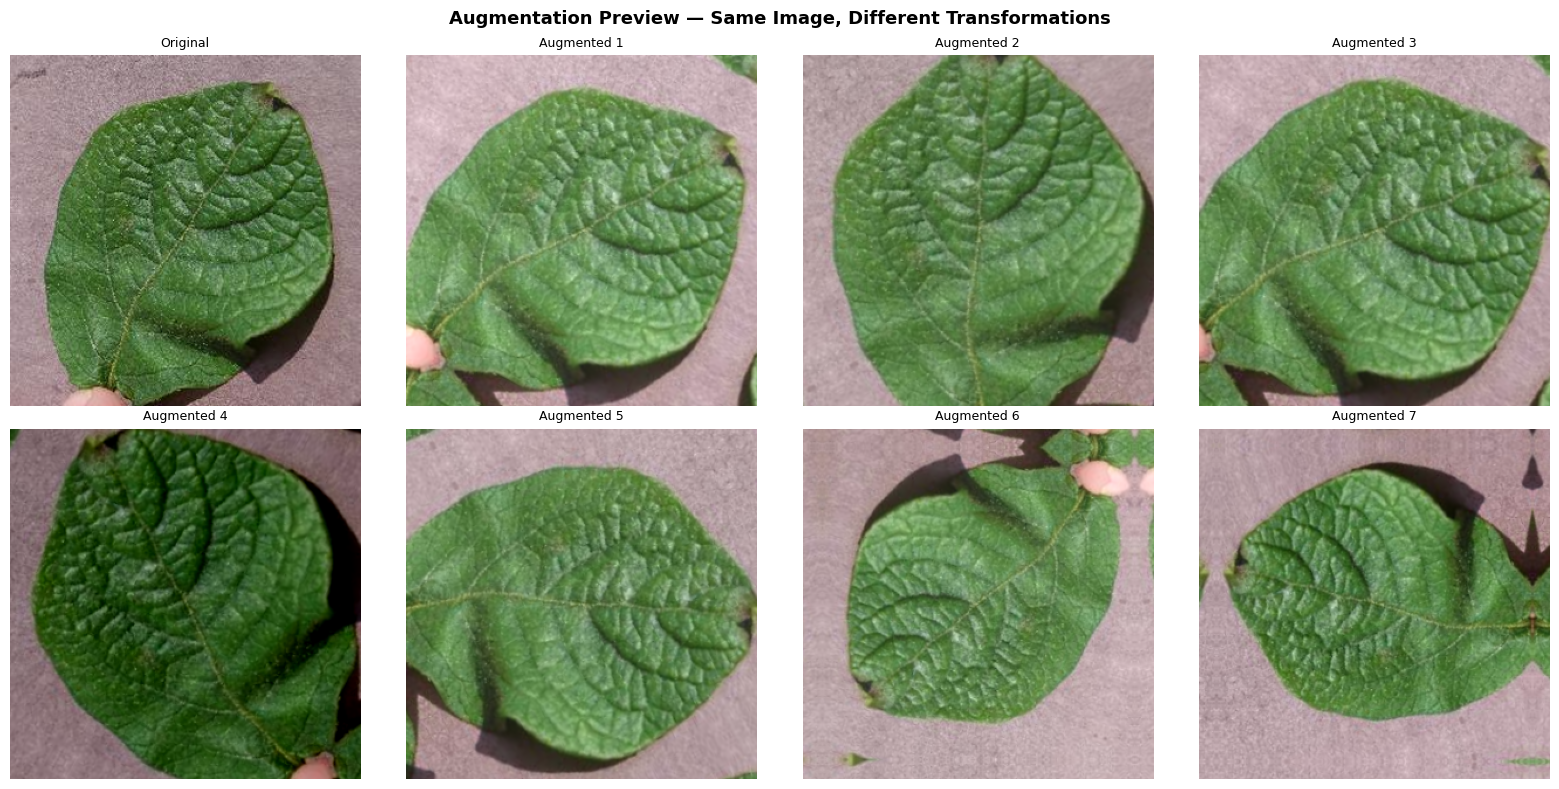

✓ Augmentation preview saved to logs/


In [11]:
plt.figure(figsize=(16, 8))
plt.suptitle('Augmentation Preview — Same Image, Different Transformations',
             fontsize=13, fontweight='bold')

# Pick one image from Potato___healthy (smallest class)
sample_class_path = os.path.join(BASE_DATASET_PATH, 'Potato___healthy')
sample_img_path   = os.path.join(sample_class_path, os.listdir(sample_class_path)[0])

original = Image.open(sample_img_path).resize(IMAGE_SIZE)
original_array = np.array(original) / 255.0

for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    if i == 0:
        ax.imshow(original_array)
        ax.set_title('Original', fontsize=9)
    else:
        img_tensor = tf.expand_dims(
            tf.cast(tf.image.resize(
                tf.image.decode_jpeg(tf.io.read_file(sample_img_path), channels=3),
                IMAGE_SIZE
            ), tf.float32) / 255.0,
            axis=0
        )
        augmented = augmentation_layer(img_tensor[0], training=True)
        ax.imshow(augmented.numpy())
        ax.set_title(f'Augmented {i}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'augmentation_preview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Augmentation preview saved to logs/")

In [12]:
# ── Save split paths to disk for training notebook ───────────
splits = {
    'paths_train'  : paths_train.tolist(),
    'paths_val'    : paths_val.tolist(),
    'paths_test'   : paths_test.tolist(),
    'labels_train' : labels_train.tolist(),
    'labels_val'   : labels_val.tolist(),
    'labels_test'  : labels_test.tolist(),
}

splits_path = os.path.join(EXPORT_DIR, 'dataset_splits.json')
with open(splits_path, 'w') as f:
    json.dump(splits, f)

print(f"✓ Dataset splits saved to {splits_path}")

# ── Save class name mapping ───────────────────────────────────
class_mapping = {str(idx): name for idx, name in enumerate(CLASS_NAMES)}
mapping_path  = os.path.join(EXPORT_DIR, 'class_mapping.json')
with open(mapping_path, 'w') as f:
    json.dump(class_mapping, f, indent=2)

print(f"✓ Class mapping saved to {mapping_path}")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"PREPROCESSING COMPLETE")
print(f"{'='*50}")
print(f"Total images         : {len(all_paths):,}")
print(f"Train / Val / Test   : {len(paths_train):,} / {len(paths_val):,} / {len(paths_test):,}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Input shape          : {IMAGE_SHAPE}")
print(f"Augmentation         : applied to train only")
print(f"Class imbalance fix  : class_weights loaded from JSON")
print(f"\nFiles saved to {EXPORT_DIR}:")
print(f"  → class_weights.json")
print(f"  → dataset_splits.json")
print(f"  → class_mapping.json")
print(f"\nNext step: 03_model_training.ipynb")
print(f"{'='*50}")

✓ Dataset splits saved to /kaggle/working/exports/dataset_splits.json
✓ Class mapping saved to /kaggle/working/exports/class_mapping.json

PREPROCESSING COMPLETE
Total images         : 54,305
Train / Val / Test   : 43,443 / 5,431 / 5,431
Batch size           : 32
Input shape          : (300, 300, 3)
Augmentation         : applied to train only
Class imbalance fix  : class_weights loaded from JSON

Files saved to /kaggle/working/exports:
  → class_weights.json
  → dataset_splits.json
  → class_mapping.json

Next step: 03_model_training.ipynb


In [13]:
for fname in ['class_weights.json', 'dataset_splits.json', 'class_mapping.json']:
    path = os.path.join(EXPORT_DIR, fname)
    size = os.path.getsize(path) / 1024
    print(f"✓ {fname} — {size:.1f} KB")

✓ class_weights.json — 1.0 KB
✓ dataset_splits.json — 8328.0 KB
✓ class_mapping.json — 1.4 KB
